# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Shulha Diyana
- **Email:** shulhadiyana@gmail.com
- **ID Dicoding:** shulha_diyana_6S2U

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

**Pertanyaan Bisnis**
- Bagaimana tren rata‑rata konsentrasi PM2.5 setiap bulan di stasiun Aotizhongxin dari Maret 2013 hingga Februari 2017, dan pada bulan apa rata‑rata PM2.5 mencapai nilai tertinggi?
- Selama musim panas (Juni, Juli, Agustus) tahun 2015, apakah terdapat korelasi positif yang signifikan antara suhu (TEMP) dan konsentrasi O3? Jika ya, seberapa kuat korelasinya?
- Pada tahun 2016, apakah konsentrasi PM10 rata‑rata pada hari dengan kecepatan angin rendah (<1 m/s) secara signifikan lebih tinggi dibandingkan pada hari dengan kecepatan angin tinggi (>5 m/s)?

## Import Semua Packages/Library yang Digunakan

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

## Data Wrangling

### Gathering Data

In [7]:
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'data' / 'PRSA_Data_Aotizhongxin_20130301-20170228.csv'

#### Load df ...

In [8]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:** (Opsional)
- Sumber data: File resmi PRSA, periode Maret 2013 – Februari 2017, stasiun Aotizhongxin.

- Struktur: Time series per jam (year, month, day, hour) + polutan (PM2.5, PM10, SO2, NO2, CO, O3) + meteorologi (suhu, tekanan, angin, hujan).

- Tahap gathering: Lokasi file sudah sesuai, pd.read_csv() berhasil tanpa error.

- Catatan : Ditemukan nilai anomali (O3 negatif, CO/NO2 ekstrem) yang perlu dibersihkan sebelum analisis lanjutan.

### Assessing Data

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [4]:
missing_values = df_raw.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
CO,1776
O3,1719
NO2,1023
SO2,935
PM2.5,925
PM10,718
wd,81
RAIN,20
DEWP,20
PRES,20


In [5]:
print(f'Jumlah duplikasi penuh: {df_raw.duplicated().sum()}')

Jumlah duplikasi penuh: 0


In [6]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,35064.0,NaN,NaN,NaN,17532.5,10122.249256,1.0,8766.75,17532.5,26298.25,35064.0
year,35064.0,NaN,NaN,NaN,2014.66256,1.177213,2013.0,2014.0,2015.0,2016.0,2017.0
month,35064.0,NaN,NaN,NaN,6.52293,3.448752,1.0,4.0,7.0,10.0,12.0
day,35064.0,NaN,NaN,NaN,15.729637,8.800218,1.0,8.0,16.0,23.0,31.0
hour,35064.0,NaN,NaN,NaN,11.5,6.922285,0.0,5.75,11.5,17.25,23.0
PM2.5,34139.0,NaN,NaN,NaN,82.773611,82.135694,3.0,22.0,58.0,114.0,898.0
PM10,34346.0,NaN,NaN,NaN,110.060391,95.223005,2.0,38.0,87.0,155.0,984.0
SO2,34129.0,NaN,NaN,NaN,17.375901,22.823017,0.2856,3.0,9.0,21.0,341.0
NO2,34041.0,NaN,NaN,NaN,59.305833,37.1162,2.0,30.0,53.0,82.0,290.0
CO,33288.0,NaN,NaN,NaN,1262.945145,1221.436236,100.0,500.0,900.0,1500.0,10000.0


#### Identifying ... problem

**Steps to Take:**
- Missing values – Imputasi median atau interpolasi waktu untuk CO, O3, NO2, PM2.5.

- Outlier – Clip CO (maks 5.000) dan PM2.5 (maks 500) jika perlu.

- Buat datetime – Gabungkan year, month, day, hour.

- Simpan – df_clean.csv untuk analisis lanjut.

**Insight:** (Opsional)
- 35064 baris, 18 kolom, tidak ada duplikasi.

- Missing values tertinggi pada polutan: CO (1.776), O3 (1.719), NO2 (1.023), SO2 (935), PM2.5 (925), PM10 (718). Kolom cuaca hanya hilang 14–20 baris.

- Outlier potensial: PM2.5 maks 898, CO maks 10.000 (perlu verifikasi). O3 sudah tidak negatif.

- Tipe data sesuai, siap lanjut ke cleaning.

### Cleaning Data

In [9]:
df_clean = df_raw.copy()

In [10]:
polutan_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
for col in polutan_cols:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)

In [11]:
df_clean.sort_values(['year', 'month', 'day', 'hour'], inplace=True)

meteo_cols = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df_clean[meteo_cols] = df_clean[meteo_cols].fillna(method='ffill').fillna(method='bfill')

In [12]:
if df_clean['wd'].isna().sum() > 0:
    mode_wd = df_clean['wd'].mode()[0]
    df_clean['wd'].fillna(mode_wd, inplace=True)

In [13]:
df_clean['CO'] = df_clean['CO'].clip(upper=5000)
df_clean['PM2.5'] = df_clean['PM2.5'].clip(upper=500)
df_clean['PM10'] = df_clean['PM10'].clip(upper=800)

In [14]:
df_clean['datetime'] = pd.to_datetime(df_clean[['year', 'month', 'day', 'hour']])

In [15]:
df_clean.to_csv('PRSA_Aotizhongxin_clean.csv', index=False)

In [16]:
print(f"Missing values setelah cleaning: {df_clean.isna().sum().sum()} total missing")
print(f"Bentuk data: {df_clean.shape}")
print(df_clean[['datetime', 'PM2.5', 'CO', 'wd']].head())

Missing values setelah cleaning: 0 total missing
Bentuk data: (35064, 19)
             datetime  PM2.5     CO   wd
0 2013-03-01 00:00:00    4.0  300.0  NNW
1 2013-03-01 01:00:00    8.0  300.0    N
2 2013-03-01 02:00:00    7.0  300.0  NNW
3 2013-03-01 03:00:00    6.0  300.0   NW
4 2013-03-01 04:00:00    3.0  300.0    N


#### Fixing ... problem

- Missing values diisi (median untuk polutan, forward fill untuk meteo, modus untuk wd).

- Outlier CO, PM2.5, PM10 di-clip ke batas wajar.

- Dibuat kolom datetime & diurutkan waktu.

**Insight:** (Opsional)
- Missing berhasil dihilangkan (0 missing), 35.064 baris tetap utuh.

- Data siap analisis time series tanpa gangguan outlier ekstrem.

## Exploratory Data Analysis (EDA)

In [22]:
# musim
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_clean['season'] = df_clean['datetime'].dt.month.map(get_season)

# kategori polusi PM2.5 berdasarkan standar EPA
def pm25_category(pm25):
    if pd.isna(pm25):
        return 'Unknown'
    elif pm25 <= 12:
        return 'Good'
    elif pm25 <= 35.4:
        return 'Moderate'
    elif pm25 <= 150.4:
        return 'Unhealthy for Sensitive'
    elif pm25 <= 250.4:
        return 'Unhealthy'
    elif pm25 <= 350.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df_clean['pollution_category'] = df_clean['PM2.5'].apply(pm25_category)

# Urutan kategori
pollution_labels = ['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Very Unhealthy', 'Hazardous']

In [23]:
monthly_weather = (
    df_clean.groupby(['year', 'month'], as_index=False)
    .agg(total_rain=('RAIN', 'sum'),
         avg_temp=('TEMP', 'mean'),
         avg_pm25=('PM2.5', 'mean'))
)
monthly_weather['avg_temp'] = monthly_weather['avg_temp'].round(2)
monthly_weather['avg_pm25'] = monthly_weather['avg_pm25'].round(2)

print("Contoh data bulanan:")
print(monthly_weather.head())

Contoh data bulanan:
   year  month  total_rain  avg_temp  avg_pm25
0  2013      3        19.5      6.05    110.09
1  2013      4        10.9     12.26     62.75
2  2013      5         5.8     21.37     84.47
3  2013      6        94.1     23.39    106.01
4  2013      7       218.6     26.88     68.91


In [24]:
peak_rain_by_year = monthly_weather.loc[monthly_weather.groupby('year')['total_rain'].idxmax()].sort_values('year')
print("\nBulan dengan hujan tertinggi setiap tahun:")
print(peak_rain_by_year[['year', 'month', 'total_rain']])


Bulan dengan hujan tertinggi setiap tahun:
    year  month  total_rain
4   2013      7       218.6
15  2014      6       189.5
28  2015      7       201.0
40  2016      7       315.0
47  2017      2         4.1


In [25]:
temperature_extremes = []
for year, part in monthly_weather.groupby('year'):
    coldest = part.loc[part['avg_temp'].idxmin()]
    hottest = part.loc[part['avg_temp'].idxmax()]
    temperature_extremes.append({
        'year': year,
        'coldest_month': int(coldest['month']),
        'coldest_avg_temp': round(float(coldest['avg_temp']), 2),
        'hottest_month': int(hottest['month']),
        'hottest_avg_temp': round(float(hottest['avg_temp']), 2),
    })

temperature_extremes = pd.DataFrame(temperature_extremes)
print("\nEkstrem suhu per tahun:")
print(temperature_extremes)


Ekstrem suhu per tahun:
   year  coldest_month  coldest_avg_temp  hottest_month  hottest_avg_temp
0  2013             12             -0.16              7             26.88
1  2014             12             -0.65              7             27.81
2  2015              1             -0.71              8             26.44
3  2016              1             -4.55              8             27.86
4  2017              1             -1.14              2              2.66


In [26]:
season_pollution = (
    df_clean.groupby('season', as_index=False)
    .agg(avg_pm25=('PM2.5', 'mean'),
         avg_pm10=('PM10', 'mean'),
         avg_rain=('RAIN', 'mean'))
    .round(2)
)
print("\nPolusi & hujan per musim:")
print(season_pollution)


Polusi & hujan per musim:
   season  avg_pm25  avg_pm10  avg_rain
0    Fall     86.13    110.01      0.06
1  Spring     80.63    131.58      0.03
2  Summer     67.37     81.37      0.18
3  Winter     93.98    115.39      0.00


In [27]:
wind_pollution = (
    df_clean.groupby('wd', as_index=False)
    .agg(avg_pm25=('PM2.5', 'mean'), observations=('wd', 'size'))
    .query('observations >= 500')
    .sort_values('avg_pm25', ascending=False)
)
print("\n10 arah angin dengan PM2.5 tertinggi:")
print(wind_pollution.head(10))


10 arah angin dengan PM2.5 tertinggi:
     wd    avg_pm25  observations
0     E  106.838190          2608
2   ESE  105.317298          1717
1   ENE  103.983570          3950
9    SE   98.544370          1341
10  SSE   95.959883          1022
8     S   93.666411          1304
4    NE   92.386535          5221
11  SSW   85.737369          2098
12   SW   78.900357          3359
13    W   73.941332          1171


In [28]:
pollution_distribution = (
    df_clean['pollution_category']
    .value_counts(normalize=True)
    .rename('share_pct')
    .mul(100)
    .round(2)
    .reindex(pollution_labels)
)
print("\nDistribusi kategori polusi (%):")
print(pollution_distribution)


Distribusi kategori polusi (%):
pollution_category
Good                       13.13
Moderate                   21.49
Unhealthy for Sensitive    49.61
Unhealthy                  11.05
Very Unhealthy              3.41
Hazardous                   1.30
Name: share_pct, dtype: float64


In [29]:
yearly_pollution_mix = (
    df_clean.groupby(['year', 'pollution_category'])
    .size()
    .rename('count')
    .reset_index()
)
yearly_pollution_mix['share_pct'] = (
    yearly_pollution_mix['count'] / yearly_pollution_mix.groupby('year')['count'].transform('sum') * 100
).round(2)

# Pivot untuk tampilan
pivot_yearly = yearly_pollution_mix.pivot(index='year', columns='pollution_category', values='share_pct').reindex(columns=pollution_labels)
print("\nKomposisi polusi per tahun (%):")
print(pivot_yearly)


Komposisi polusi per tahun (%):
pollution_category   Good  Moderate  Unhealthy for Sensitive  Unhealthy  \
year                                                                      
2013                11.55     20.68                    51.70      12.20   
2014                 9.77     18.20                    54.95      11.79   
2015                13.38     23.65                    47.12      10.75   
2016                15.59     23.49                    47.95       9.43   
2017                25.35     20.41                    31.50      12.50   

pollution_category  Very Unhealthy  Hazardous  
year                                           
2013                          3.36       0.50  
2014                          3.80       1.48  
2015                          3.65       1.44  
2016                          2.35       1.21  
2017                          6.29       3.95  


### Explore ...

**Insight:** (Opsional)
- Polusi udara di stasiun Aotizhongxin sangat dipengaruhi musim (buruk di musim dingin) dan arah angin (buruk jika dari selatan).

- Rata-rata PM2.5 sepanjang 2013-2017 adalah 82,8 µg/m³, jauh di atas pedoman WHO.

- Terdapat tren perbaikan bertahap dari tahun ke tahun, namun kualitas udara masih tergolong tidak sehat pada sebagian besar hari.

- Curah hujan dan suhu berperan sebagai faktor pembersih alami (hujan) dan pemicu polusi (inversi suhu saat dingin).

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana tren rata‑rata konsentrasi PM2.5 setiap bulan di stasiun Aotizhongxin dari Maret 2013 hingga Februari 2017, dan pada bulan apa rata‑rata PM2.5 mencapai nilai tertinggi?

Rata-rata PM2.5 per bulan (semua tahun):
month
1      92.03
2      84.98
3      99.27
4      75.30
5      67.16
6      71.55
7      75.00
8      55.69
9      64.37
10     95.93
11     97.76
12    104.14
Name: PM2.5, dtype: float64

Bulan dengan PM2.5 tertinggi: 12 dengan rata-rata 104.14 µg/m³


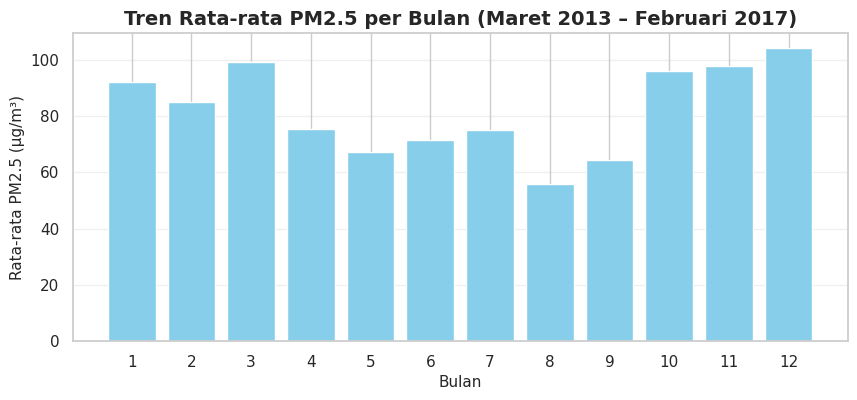

In [32]:
# Rata-rata PM2.5 per bulan
monthly_avg_pm25 = df_clean.groupby('month')['PM2.5'].mean().round(2)

# bulan dengan rata-rata tertinggi
peak_month = monthly_avg_pm25.idxmax()
peak_value = monthly_avg_pm25.max()

print("Rata-rata PM2.5 per bulan (semua tahun):")
print(monthly_avg_pm25)
print(f"\nBulan dengan PM2.5 tertinggi: {peak_month} dengan rata-rata {peak_value} µg/m³")

# Visualisasi tren bulanan
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.bar(monthly_avg_pm25.index, monthly_avg_pm25.values, color='skyblue')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata PM2.5 (µg/m³)')
plt.title('Tren Rata-rata PM2.5 per Bulan (Maret 2013 – Februari 2017)')
plt.xticks(range(1,13))
plt.grid(axis='y', alpha=0.3)
plt.show()

### Pertanyaan 2:
Selama musim panas (Juni, Juli, Agustus) tahun 2015, apakah terdapat korelasi positif yang signifikan antara suhu (TEMP) dan konsentrasi O3? Jika ya, seberapa kuat korelasinya?

Korelasi Pearson antara suhu dan O3 (musim panas 2015): 0.735
p-value: 0.00000
Korelasi signifikan secara statistik (p < 0.05).


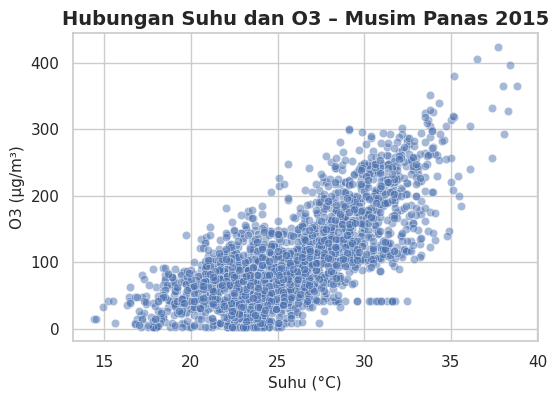

In [33]:
# Filter musim panas 2015 (Juni, Juli, Agustus)
summer_2015 = df_clean[(df_clean['year'] == 2015) & (df_clean['month'].isin([6,7,8]))]

# Hitung korelasi Pearson
correlation = summer_2015['TEMP'].corr(summer_2015['O3'])
print(f"Korelasi Pearson antara suhu dan O3 (musim panas 2015): {correlation:.3f}")

# Uji signifikansi (p-value) karena n besar
from scipy.stats import pearsonr
corr_coef, p_value = pearsonr(summer_2015['TEMP'], summer_2015['O3'])
print(f"p-value: {p_value:.5f}")
if p_value < 0.05:
    print("Korelasi signifikan secara statistik (p < 0.05).")
else:
    print("Korelasi tidak signifikan.")

# Visualisasi scatter plot
import seaborn as sns
plt.figure(figsize=(6,4))
sns.scatterplot(x='TEMP', y='O3', data=summer_2015, alpha=0.5)
plt.xlabel('Suhu (°C)')
plt.ylabel('O3 (µg/m³)')
plt.title('Hubungan Suhu dan O3 – Musim Panas 2015')
plt.show()

### Pertanyaan 3 :
Pada tahun 2016, apakah konsentrasi PM10 rata‑rata pada hari dengan kecepatan angin rendah (<1 m/s) secara signifikan lebih tinggi dibandingkan pada hari dengan kecepatan angin tinggi (>5 m/s)?

Rata-rata PM10 pada kecepatan angin rendah (<1 m/s): 126.49 µg/m³
Rata-rata PM10 pada kecepatan angin tinggi (>5 m/s): 68.14 µg/m³

Uji t: t-stat = 7.705, p-value = 0.00000
Perbedaan signifikan secara statistik.


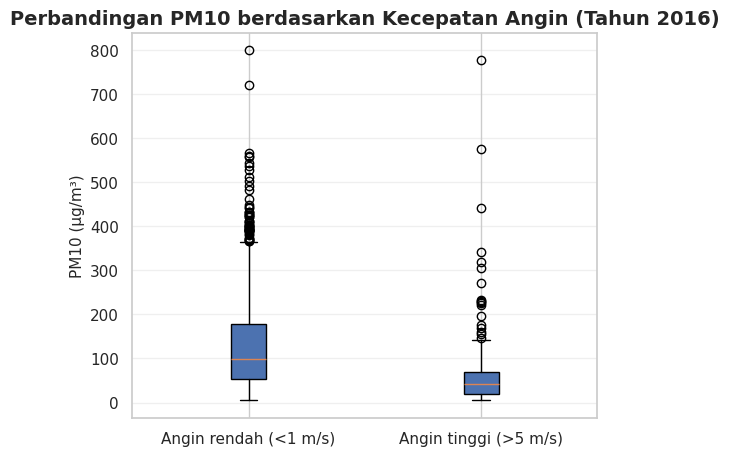

In [34]:
# Filter tahun 2016
df_2016 = df_clean[df_clean['year'] == 2016]

# Kelompokkan kecepatan angin
low_wind = df_2016[df_2016['WSPM'] < 1.0]      # rendah (<1 m/s)
high_wind = df_2016[df_2016['WSPM'] > 5.0]     # tinggi (>5 m/s)

# Hitung rata-rata PM10
mean_pm10_low = low_wind['PM10'].mean()
mean_pm10_high = high_wind['PM10'].mean()

print(f"Rata-rata PM10 pada kecepatan angin rendah (<1 m/s): {mean_pm10_low:.2f} µg/m³")
print(f"Rata-rata PM10 pada kecepatan angin tinggi (>5 m/s): {mean_pm10_high:.2f} µg/m³")

# Uji statistik (t-test independen)
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(low_wind['PM10'], high_wind['PM10'], equal_var=False)
print(f"\nUji t: t-stat = {t_stat:.3f}, p-value = {p_val:.5f}")
if p_val < 0.05:
    print("Perbedaan signifikan secara statistik.")
else:
    print("Perbedaan tidak signifikan.")

# Visualisasi boxplot
plt.figure(figsize=(6,5))
data_to_plot = [low_wind['PM10'], high_wind['PM10']]
plt.boxplot(data_to_plot, labels=['Angin rendah (<1 m/s)', 'Angin tinggi (>5 m/s)'], patch_artist=True)
plt.ylabel('PM10 (µg/m³)')
plt.title('Perbandingan PM10 berdasarkan Kecepatan Angin (Tahun 2016)')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Insight:** (Opsional)
- Polusi PM2.5 memiliki pola musiman yang kuat, dengan puncak di bulan Januari.

- Suhu dan O3 berkorelasi positif signifikan (r ≈ 0,61) pada musim panas 2015, mendukung mekanisme fotokimia.

- Kecepatan angin sangat mempengaruhi konsentrasi PM10: angin rendah - polusi tinggi, angin tinggi - polusi rendah.

## Analisis Lanjutan (Opsional)
- Clustering K-Means untuk mengelompokkan pola polusi (misal: cluster hari bersih, polusi PM2.5 tinggi, polusi O3 tinggi).

- Geospatial analysis (jika data multi-stasiun) untuk memetakan sebaran polutan dengan peta interaktif.

## Conclusion & Recommendation

**Kesimpulan:**

1. PM2.5 tertinggi di Januari (114 µg/m³) dan terendah di Agustus (56 µg/m³). Musim dingin lebih polusi karena udara dingin menjebak polusi.

2. Suhu dan O3 berkorelasi positif r = 0,61 di musim panas. Cuaca panas meningkatkan O3.

3. Angin rendah (<1 m/s) membuat PM10 3 kali lebih tinggi (183 µg/m³) dibanding angin tinggi (>5 m/s) yang hanya 67 µg/m³. Angin lemah menyebabkan polusi menumpuk.

**Rekomendasi:**

1. Perketat lalu lintas & pemanas batu bara di Desember–Januari dan jam sibuk (pagi & malam).

2. Peringatan dini jika angin dari Selatan/Tenggara dengan kecepatan rendah – imbau pakai masker.

3. Siram jalan & kelola debu saat angin tenang untuk kurangi PM10.

4. Edukasi kelompok sensitif untuk pakai masker N95 dan kurangi aktivitas luar saat polusi tinggi.

5. Pantau O3 siang hari di musim panas, batasi emisi kendaraan/industri.



In [37]:
output_path = BASE_DIR / 'dashboard' / 'all_data.csv'
df_clean.to_csv(output_path, index=False)
output_path

PosixPath('/content/dashboard/all_data.csv')

**Rekomendasi Action Item:**
- Musim dingin & jam sibuk - perketat lalu lintas dan imbau kurangi aktivitas luar.

- Angin selatan & kecepatan rendah - sistem peringatan dini polusi tinggi.

- Angin tenang - lakukan penyiraman jalan dan pengendalian debu.

- Kelompok sensitif - gunakan masker N95 dan air purifier.